In [ ]:
# --- repo-root bootstrap ---
# This notebook lives in 05_analysis/ but reads and writes paths relative to
# the repo root (data/, metrics_data/, outputs/, figures_*/) and imports
# modules from the repo root and 04_metrics/. Jupyter's working directory is
# the notebook's own folder, so without this cell those paths resolve under
# 05_analysis/ and the imports fail. Idempotent - safe to re-run.
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
for _p in (REPO_ROOT, REPO_ROOT / "04_metrics"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
print(f"repo root: {REPO_ROOT}")


# Gručenje algoritmov po merah — vizualna primerjava komplementarnosti

Za izbrane mere podobnosti (vse razen deleža vračanja/Jaccarda) zgradimo
algoritem×algoritem matriko razdalj in prikažemo dendrograme drug ob drugem.
Cilj: pokazati, da se **isti** algoritmi grupirajo **različno** glede na to,
katero mero uporabimo — vizualni argument za komplementarnost, ki dopolni
Spearmanovo analizo.

Vseh šest mer je v `merged_dim_{d}.csv` že na voljo kot **razdalja**
(0 = enako), zato jih uporabimo neposredno, brez pretvorbe iz podobnosti.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# ---- nastavitve ----
DIM = 10
MERGED_PATH = f'metrics_data/merged/merged_dim_{DIM}.csv'

# vse mere razen deleza vracanja (Jaccard) - po dogovoru
METRICS = ['entropy', 'cosine', 'cosine_columns', 'exploration', 'location', 'fitness']
KEYS = ['Algorithm1', 'Algorithm2']

# SAMO ti algoritmi bodo v matrikah/dendrogramih - vpisi svoj izbor
ALGOS = ["OriginalDE","SADE","AugmentedAEO", "OriginalGWO", "OriginalALO"]

# lepa imena za naslove panelov
METRIC_TITLES = {
    'entropy': 'Entropija',
    'cosine': 'Kosinusna (globalna)',
    'cosine_columns': 'Kosinusna po grucah',
    'exploration': 'Raziskovanje/izkoriscanje',
    'location': 'Lokacija',
    'fitness': 'Fitness',
}

In [32]:
# 1. nalozi, filtriraj na ALGOS, agregiraj po paru (povprecje cez funkcije/instance/zagone)
df = pd.read_csv(MERGED_PATH)

df_filtered = df[df['Algorithm1'].isin(ALGOS) & df['Algorithm2'].isin(ALGOS)]
if df_filtered.empty:
    raise ValueError("Noben par v ALGOS ni najden v merged datoteki - preveri imena/pisavo.")

missing = set(ALGOS) - (set(df_filtered['Algorithm1']) | set(df_filtered['Algorithm2']))
if missing:
    print(f'  [opozorilo] ti algoritmi iz ALGOS niso najdeni v podatkih: {missing}')

pair_means = df_filtered.groupby(KEYS)[METRICS].mean().reset_index()

algos = sorted(set(pair_means['Algorithm1']) | set(pair_means['Algorithm2']))
print(f'algoritmov (po filtru): {len(algos)}, parov: {len(pair_means)}')
pair_means.head()

algoritmov (po filtru): 5, parov: 10


,Algorithm1,Algorithm2,entropy,cosine,cosine_columns,exploration,location,fitness
0,AugmentedAEO,OriginalALO,0.045907,0.904331,0.855435,0.044111,6.018538,3078.615363
1,AugmentedAEO,OriginalDE,0.092130,0.971132,0.874274,0.112445,6.288837,136431.651535
2,AugmentedAEO,OriginalGWO,0.152616,0.853420,0.843607,0.148348,5.292246,1559.501746
3,AugmentedAEO,SADE,0.436602,0.773537,0.885858,0.340352,4.979200,337.155452
4,OriginalALO,OriginalDE,0.078662,0.982859,0.822712,0.098868,6.071925,134341.226275


## Tabela vrednosti — vrste = pari, stolpci = mere

Surove vrednosti (brez uskladitve skale) za vsak par znotraj `ALGOS`, po
vseh šestih merah. To pokaže natančne številke, ne le vizualno dendrogramsko
strukturo.

In [33]:
# tabela: vrste = pari algoritmov, stolpci = mere (surove vrednosti)
table_raw = pair_means.copy()
table_raw['par'] = table_raw['Algorithm1'] + ' / ' + table_raw['Algorithm2']
table_raw = table_raw.set_index('par')[METRICS]

print(f'{len(table_raw)} parov x {len(METRICS)} mer')
table_raw

10 parov x 6 mer


,entropy,cosine,cosine_columns,exploration,location,fitness
par,,,,,,
AugmentedAEO / OriginalALO,0.045907,0.904331,0.855435,0.044111,6.018538,3078.615363
AugmentedAEO / OriginalDE,0.092130,0.971132,0.874274,0.112445,6.288837,136431.651535
AugmentedAEO / OriginalGWO,0.152616,0.853420,0.843607,0.148348,5.292246,1559.501746
AugmentedAEO / SADE,0.436602,0.773537,0.885858,0.340352,4.979200,337.155452
OriginalALO / OriginalDE,0.078662,0.982859,0.822712,0.098868,6.071925,134341.226275
OriginalALO / OriginalGWO,0.144740,0.889284,0.804703,0.147927,5.297633,4164.125604
OriginalALO / SADE,0.427901,0.849044,0.840938,0.335150,5.249337,3096.586996
OriginalDE / OriginalGWO,0.136130,0.973273,0.828502,0.126018,5.661403,135029.193491
OriginalDE / SADE,0.362866,0.918167,0.818357,0.243369,5.443701,136144.462159


## Heatmap iste tabele (uskladeni skali)

Mere so na zelo različnih skalah (entropija/kosinusni ~[0,1], raziskovanje
[0,100], lokacija/fitness neomejeni), zato jih za skupen heatmap uskladimo:
raziskovanje delimo s 100, lokacijo in fitness min-max normaliziramo
**znotraj izbranega `ALGOS` nabora** (ne čez vseh 28 algoritmov, ker
analiziramo samo ta pod-nabor). Pričakovano je, da bo slika mestoma "čudna"
zaradi teh razlik v skali — zato imamo zgoraj tudi surovo tabelo.

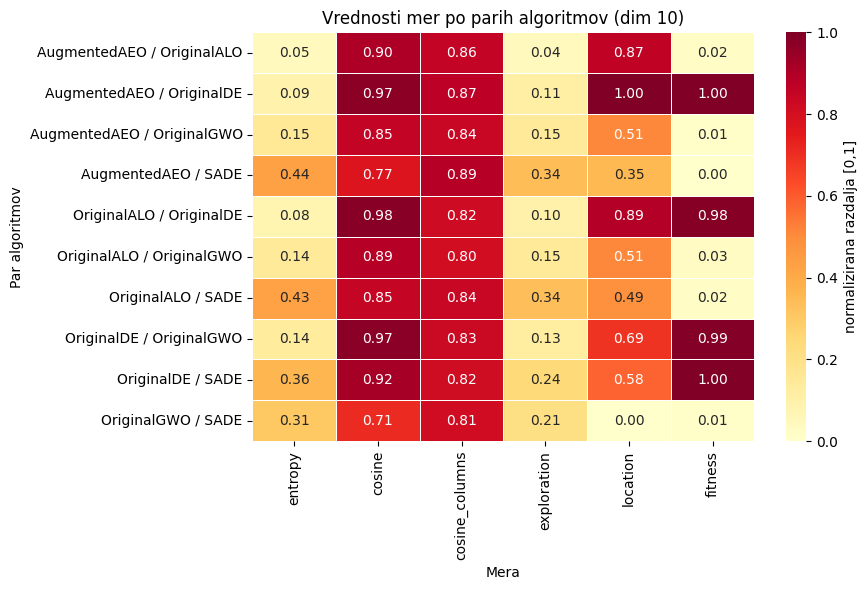

In [34]:
import seaborn as sns

MINMAX = ['location', 'fitness']

table_scaled = table_raw.copy()
for m in MINMAX:
    lo, hi = table_scaled[m].min(), table_scaled[m].max()
    table_scaled[m] = (table_scaled[m] - lo) / (hi - lo) if hi > lo else 0.0

plt.figure(figsize=(9, 0.4 * len(table_scaled) + 2))
sns.heatmap(table_scaled, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'normalizirana razdalja [0,1]'})
plt.title(f'Vrednosti mer po parih algoritmov (dim {DIM})')
plt.xlabel('Mera')
plt.ylabel('Par algoritmov')
plt.tight_layout()
os.makedirs('figures_results', exist_ok=True)
plt.savefig(f'figures_results/tabela_mer_dim_{DIM}.pdf', bbox_inches='tight')
plt.show()

In [35]:
def build_distance_matrix(pair_df, metric, algos):
    """Simetricna algoritem x algoritem matrika razdalj za eno mero."""
    n = len(algos)
    M = pd.DataFrame(np.zeros((n, n)), index=algos, columns=algos)
    for _, row in pair_df.iterrows():
        a1, a2, val = row['Algorithm1'], row['Algorithm2'], row[metric]
        M.loc[a1, a2] = val
        M.loc[a2, a1] = val
    return M


def plot_dendrogram_on_ax(matrix, ax, title, family_map, palette, method='average'):
    """Narise en dendrogram na dano os, z listi obarvanimi po druzini."""
    dist_vals = matrix.values.copy()
    np.fill_diagonal(dist_vals, 0.0)
    dist_vals = (dist_vals + dist_vals.T) / 2  # zagotovi simetrijo
    if np.any(np.isnan(dist_vals)):
        fill_val = np.nanmax(dist_vals) if np.any(~np.isnan(dist_vals)) else 1.0
        dist_vals = np.nan_to_num(dist_vals, nan=fill_val)

    Z = linkage(squareform(dist_vals, checks=False), method=method)
    dn = dendrogram(Z, labels=list(matrix.index), ax=ax, leaf_rotation=90, no_labels=False)

    def fam(a):
        for f, members in family_map.items():
            if a in members:
                return f
        return 'Other'

    for lbl in ax.get_xticklabels():
        lbl.set_color(palette[fam(lbl.get_text())])
        lbl.set_fontsize(6)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('razdalja')

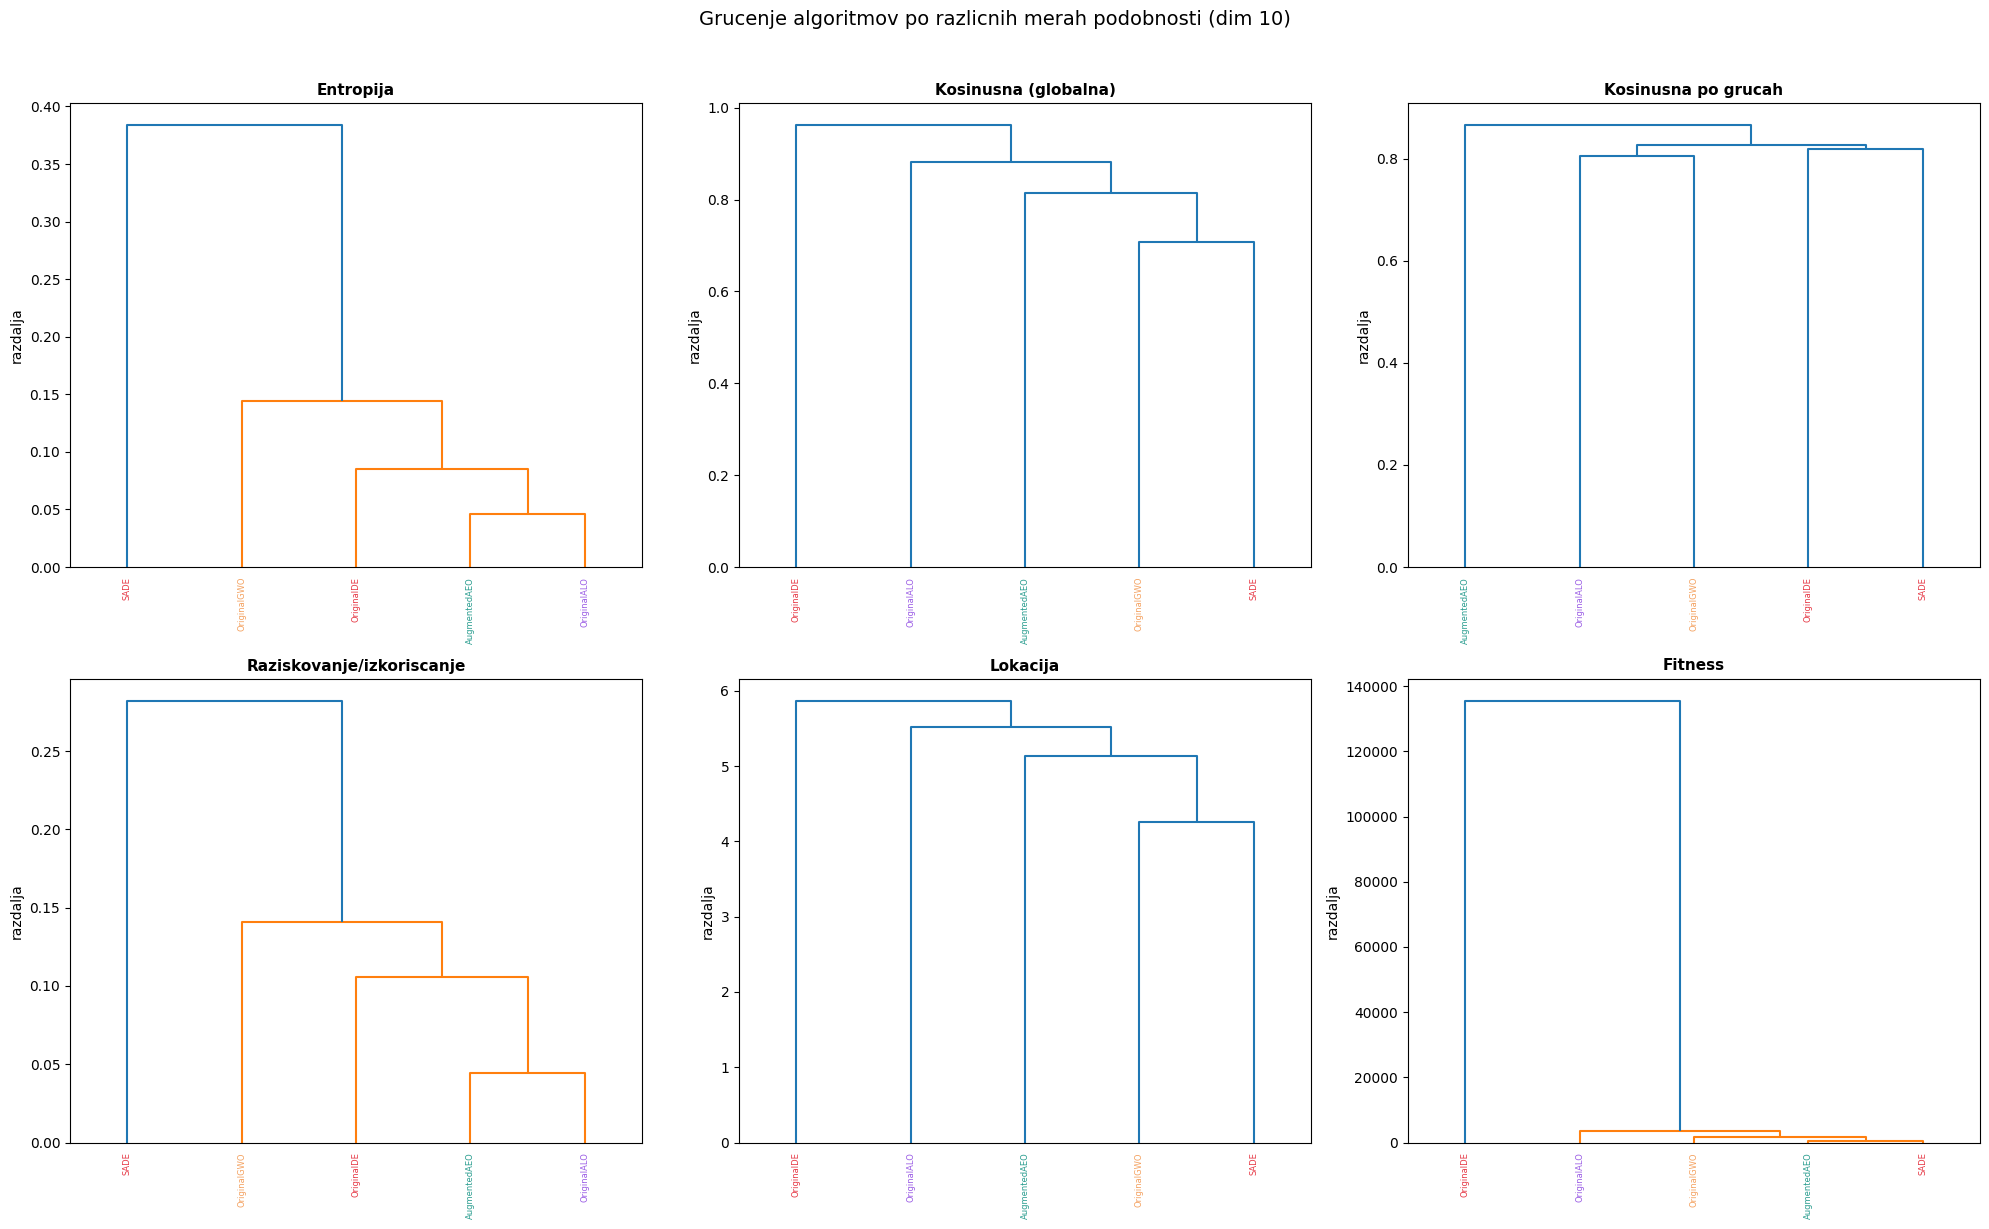

In [36]:
# druzine algoritmov (za barvanje listov dendrograma)
family_map = {
    'DE': ['JADE', 'OriginalDE', 'SADE', 'OriginalSHADE', 'L_SHADE'],
    'AEO': ['ModifiedAEO', 'OriginalAEO', 'AugmentedAEO'],
    'WOA': ['OriginalWOA', 'HI_WOA', 'WhaleFOA', 'GWO_WOA'],
    'GWO': ['OriginalGWO', 'IGWO', 'RW_GWO'],
}
palette = {'DE': '#e63946', 'AEO': '#2a9d8f', 'WOA': '#457b9d',
           'GWO': '#f4a261', 'Other': '#9b5de5'}

# 2. zgradi matriko za vsako mero
matrices = {m: build_distance_matrix(pair_means, m, algos) for m in METRICS}

# 3. vecpanelna slika: 2 vrstici x 3 stolpci, en dendrogram na mero
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    plot_dendrogram_on_ax(matrices[metric], ax, METRIC_TITLES[metric], family_map, palette)

fig.suptitle(f'Grucenje algoritmov po razlicnih merah podobnosti (dim {DIM})', fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs('figures_results', exist_ok=True)
plt.savefig(f'figures_results/grucenje_po_metrikah_dim_{DIM}.pdf', bbox_inches='tight')
plt.show()